# Hito 1 — Adquisición y Planteo
## TPI: Diagnóstico de Desempeño Académico

**Dataset:** *Student Social Media And Mental Health Impact* (Kaggle) — 5000 registros, 13 variables.

El objetivo es diagnosticar el desempeño académico a partir de los hábitos digitales y de
bienestar de los estudiantes, identificar factores de riesgo y proponer mejoras basadas en evidencia.

> **Nota:** el dataset no trae una variable directa de nota/abandono. El **riesgo académico**
> se construirá como variable calculada (Índice de Riesgo) en el Hito 2, a partir de
> `Study_Hours`, `Stress_Level` y `Mental_Health_Score`.

### Preguntas de negocio
1. **La huella digital del riesgo:** ¿qué combinación de hábitos digitales (horas de uso,
   desbloqueos, plataforma, propósito) caracteriza al estudiante en riesgo académico?
2. **El umbral y el mecanismo:** ¿existe un umbral de horas de redes a partir del cual caen
   el sueño y el estudio? ¿El daño viene más por desplazar el estudio o por robar sueño?
3. **Segmentos más expuestos:** a igualdad de horas de uso, ¿qué segmentos (nivel académico,
   propósito, plataforma) concentran mayor riesgo?


## Carga del dataset
El CSV ya está descargado localmente, así que se carga directamente con `pandas`.

In [30]:
import pandas as pd
import numpy as np


CSV_PATH = "Student Social Media And Mental Health Impact.csv"

try:
    df = pd.read_csv(CSV_PATH)
    print(f"Dataset cargado correctamente: {df.shape[0]} filas x {df.shape[1]} columnas")
except FileNotFoundError:
    raise FileNotFoundError(
        f"No se encontro '{CSV_PATH}'. Verifica que el CSV este en el mismo directorio del notebook."
    )

df.head()


Dataset cargado correctamente: 5000 filas x 13 columnas


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## Verificación rápida (cierre del Hito 1)
Confirmamos volumen, tipos y disponibilidad de las variables que usan las 3 preguntas.

In [31]:
# Volumen y tipos
print("Registros:", len(df), "(minimo requerido: 5000)")
print("Variables:", list(df.columns))
print()
df.info()


Registros: 5000 (minimo requerido: 5000)
Variables: ['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Stress_Level', 'Mental_Health_Score']

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity

In [32]:
# Vistazo a las variables clave de cada pregunta de negocio
print("== Categoricas ==")
for col in ["Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Stress_Level"]:
    # print(f"\n{col}:")
    print( df[col].value_counts(), f"\n")

print()
print("== Numericas (proxies de habito / bienestar) ==")
print(df[["Avg_Daily_Usage_Hours", "Daily_Unlocks", "Study_Hours","Sleep_Hours_Per_Night", "Mental_Health_Score"]].describe().round(2))


== Categoricas ==
Academic_Level
Undergraduate    3632
Graduate          918
High School       450
Name: count, dtype: int64 

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64 

Purpose_Of_Use
Entertainment    2552
Education        1094
Networking        793
News              561
Name: count, dtype: int64 

Stress_Level
Very High    1621
High         1440
Medium       1295
Low           644
Name: count, dtype: int64 


== Numericas (proxies de habito / bienestar) ==
       Avg_Daily_Usage_Hours  Daily_Unlocks  Study_Hours  \
count                5000.00        5000.00      5000.00   
mean                    5.08         171.45         3.01   
std                     1.65          42.86         1.64   
min                     1.00          62.00         0.30   
25%              

---
# Hito 2 — ETL, Calidad de Datos y Feature Engineering

En este hito **diagnosticamos** la calidad del dataset, aplicamos una **limpieza justificada**
y creamos las **variables calculadas** que responden las 3 preguntas de negocio. Todo el
proceso se organiza en **funciones modulares** (migraran a `etl.py` en el Hito 4) con
manejo de errores `try/except` en las etapas criticas.


## 2.1 Diagnostico de calidad de datos
Antes de tocar nada, medimos: nulos, duplicados, rangos imposibles y outliers estadisticos
(metodo IQR). La limpieza se decide sobre esta evidencia, no a ciegas.

In [33]:

def diagnostico_calidad(df):
    """Reporta nulos, duplicados, rangos y outliers IQR sin modificar el DataFrame."""
    print("Nulos por columna:", df.isna().sum().sum(), "(total)")
    print("Filas duplicadas :", df.duplicated().sum())

    print("\nRangos numericos y outliers IQR:")
    for c in df.select_dtypes(include=np.number).columns:
        q1, q3 = df[c].quantile([.25, .75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out = ((df[c] < lo) | (df[c] > hi)).sum()
        neg = (df[c] < 0).sum()
        print(f"  {c:25s} min={df[c].min():7.2f} | max={df[c].max():7.2f} "
              f"| negativos={neg:3d} | outliers_IQR={out:3d}")

diagnostico_calidad(df)


Nulos por columna: 0 (total)
Filas duplicadas : 2

Rangos numericos y outliers IQR:
  Age                       min=  18.00 | max=  24.00 | negativos=  0 | outliers_IQR=  0
  Avg_Daily_Usage_Hours     min=   1.00 | max=   8.80 | negativos=  0 | outliers_IQR=  0
  Daily_Unlocks             min=  62.00 | max= 273.00 | negativos=  0 | outliers_IQR=  0
  Study_Hours               min=   0.30 | max=   8.30 | negativos=  0 | outliers_IQR=  2
  Physical_Activity_Hours   min=  -0.40 | max=   4.10 | negativos= 10 | outliers_IQR= 22
  Sleep_Hours_Per_Night     min=   3.60 | max=   9.90 | negativos=  0 | outliers_IQR=  0
  Mental_Health_Score       min=   3.60 | max=   9.40 | negativos=  0 | outliers_IQR=  0


## 2.2 Limpieza
Decisiones tomadas y su justificacion:

| Hallazgo | Decision | Por que |
|----------|----------|---------|
| **2 filas duplicadas exactas** | Eliminar | Son registros repetidos: no agregan informacion y sesgarian los conteos y frecuencias. |
| **Strings categoricos** | `strip()` + tipado | Aunque vienen limpios, normalizamos por robustez (defensivo ante nuevas cargas). |
| **`Stress_Level`** | Categorica **ordenada** (`Low<Medium<High<Very High`) | Tiene orden natural; habilita el encoding ordinal del indice y el orden correcto en los graficos. |
| **10 negativos en `Physical_Activity_Hours`** | Acotar a 0 (`clip`) | Horas negativas son **fisicamente imposibles** (error de medicion). `0` = sedentario es plausible y conserva el resto de la fila. |
| **Outliers IQR (pocos)** en `Study_Hours` y `Physical_Activity_Hours` | **Winsorizar** (acotar a los limites IQR), **no eliminar** | Son muy pocos y representan justo los **perfiles extremos de riesgo** que queremos estudiar. Eliminarlos borraria senal valiosa y bajaria del minimo de 5000. El *capping* limita su apalancamiento sin perder la fila. |

> Detectamos los outliers con un **metodo estadistico (IQR)** y los **tratamos por acotacion**:
> es una eleccion critica, no mecanica. Borrar a los estudiantes de uso extremo seria borrar
> el fenomeno que el TPI busca diagnosticar.

In [34]:
CAT_COLS = ["Gender", "Country", "Academic_Level","Most_Used_Platform", "Purpose_Of_Use", "Stress_Level"]
ORDEN_ESTRES = ["Low", "Medium", "High", "Very High"]

def winsorize_iqr(serie, k=1.5):
    """Acota una serie a los limites IQR (winsorizacion). No elimina filas."""
    q1, q3 = serie.quantile([.25, .75])
    iqr = q3 - q1
    return serie.clip(q1 - k * iqr, q3 + k * iqr)

def limpiar_datos(df):
    """Limpieza completa y justificada. Devuelve un DataFrame nuevo."""
    try:
        df = df.copy()
        n0 = len(df)

        # 1) Duplicados exactos -> eliminar
        df = df.drop_duplicates().reset_index(drop=True)

        # 2) Normalizacion de strings (defensivo)
        for c in CAT_COLS:
            df[c] = df[c].astype(str).str.strip()

        # 3) Estres como categorica ORDENADA (orden natural del riesgo)
        df["Stress_Level"] = pd.Categorical(df["Stress_Level"],
                                            categories=ORDEN_ESTRES, ordered=True)

        # 4) Horas de actividad fisica negativas -> imposibles -> acotar a 0
        n_neg = int((df["Physical_Activity_Hours"] < 0).sum())
        df["Physical_Activity_Hours"] = df["Physical_Activity_Hours"].clip(lower=0)

        # 5) Outliers IQR -> winsorizar (preservar filas y senal)
        for c in ["Study_Hours", "Physical_Activity_Hours"]:
            df[c] = winsorize_iqr(df[c])

        print(f"Limpieza OK | duplicados eliminados: {n0 - len(df)} | "
              f"negativos corregidos: {n_neg} | filas finales: {len(df)}")
        return df
    except KeyError as e:
        raise KeyError(f"Falta una columna esperada durante la limpieza: {e}") from e

df = limpiar_datos(df)
df.head()


Limpieza OK | duplicados eliminados: 2 | negativos corregidos: 10 | filas finales: 4998


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## 2.3 Feature Engineering
Creamos variables calculadas que no existen en el dataset crudo pero son **necesarias para
responder las preguntas**. Cada una se justifica abajo.

### A) Indice de Riesgo Academico - *la variable central del TPI*
**Que:** un puntaje continuo `0-1` (0 = sin riesgo, 1 = riesgo maximo) que combina las tres
dimensiones del desempeno/bienestar.
**Por que asi:**
- El dataset **no tiene** una nota ni un "abandono". Necesitamos un proxy del riesgo academico.
- Lo construimos con tres senales **validadas por correlacion** (Hito 1): `Study_Hours`
  (compromiso academico), `Stress_Level` (carga de estres) y `Mental_Health_Score` (bienestar).
- Normalizamos cada componente a `0-1` para que **pesen lo mismo pese a tener escalas distintas**.
- Invertimos `Study_Hours` y `Mental_Health_Score` (mas estudio / mas salud = **menos** riesgo);
  el estres se usa directo (mas estres = mas riesgo).
- **Pesos iguales (1/3 cada uno):** decision transparente y sin parametros arbitrarios; no hay
  fundamento previo para privilegiar una dimension sobre otra.

De ese indice derivamos:
- **`Risk_Level`** (Bajo/Medio/Alto por **terciles**): segmenta en 3 grupos **balanceados**
  (~1/3 c/u) -> cada segmento tiene tamano suficiente para comparar (potencia estadistica).
- **`En_Riesgo`** (booleano, `Risk_Level == "Alto"`): version binaria para los cruces de Q1 y Q3.

### B) Features para la Q2 (umbral y mecanismo)
- **`Usage_Level`** (cuartiles de horas de uso): para **detectar el umbral** comparando sueno
  y estudio entre niveles de uso. Cuartiles = cortes **data-driven** y balanceados.
- **`Sleep_Deficit`** (booleano, `< 7 h`): umbral de la **recomendacion de sueno** para adultos
  jovenes (7-9 h). Aisla el **mecanismo** "redes -> robar sueno".

### C) Features para la Q1 (huella digital del riesgo)
- **`Unlocks_Per_Hour`** = desbloqueos / horas de uso: mide la **fragmentacion / compulsividad**
  del uso (no cuanto, sino *que tan picoteado*). Un mismo total de horas puede ser muy distinto.
- **`Study_Usage_Ratio`** = horas de estudio / horas de uso: mide la **priorizacion** del estudio
  frente a la pantalla. Es la "huella" conductual que buscamos en la Q1.


In [35]:
def _minmax(serie):
    """Normaliza a rango 0-1 (robusto porque ya winsorizamos los extremos)."""
    return (serie - serie.min()) / (serie.max() - serie.min())

def agregar_features(df):
    """Crea las variables calculadas. Devuelve un DataFrame nuevo."""
    df = df.copy()

    # Encoding ordinal del estres: Low=0 ... Very High=3
    df["Stress_Num"] = df["Stress_Level"].cat.codes

    # --- A) Indice de Riesgo Academico (pesos iguales 1/3) ---
    r_estudio = 1 - _minmax(df["Study_Hours"])          # poco estudio  -> mas riesgo
    r_estres  = df["Stress_Num"] / 3                     # mas estres    -> mas riesgo
    r_salud   = 1 - _minmax(df["Mental_Health_Score"])  # baja salud    -> mas riesgo
    df["Risk_Index"] = ((r_estudio + r_estres + r_salud) / 3).round(3)
    df["Risk_Level"] = pd.qcut(df["Risk_Index"], 3, labels=["Bajo", "Medio", "Alto"])
    df["En_Riesgo"]  = df["Risk_Level"].eq("Alto")

    # --- B) Features para la Q2 (umbral y mecanismo) ---
    df["Usage_Level"]   = pd.qcut(df["Avg_Daily_Usage_Hours"], 4,
                                  labels=["Bajo", "Moderado", "Alto", "Muy alto"],
                                  duplicates="drop")
    df["Sleep_Deficit"] = df["Sleep_Hours_Per_Night"] < 6   

    # --- C) Features para la Q1 (huella digital) ---
    df["Unlocks_Per_Hour"]  = (df["Daily_Unlocks"] / df["Avg_Daily_Usage_Hours"]).round(1)
    df["Study_Usage_Ratio"] = (df["Study_Hours"] / df["Avg_Daily_Usage_Hours"]).round(2)

    return df

df = agregar_features(df)
df[["Risk_Index", "Risk_Level", "En_Riesgo", "Usage_Level",
    "Sleep_Deficit", "Unlocks_Per_Hour", "Study_Usage_Ratio"]].head()


,Risk_Index,Risk_Level,En_Riesgo,Usage_Level,Sleep_Deficit,Unlocks_Per_Hour,Study_Usage_Ratio
0,0.418,Bajo,False,Moderado,False,33.5,1.12
1,0.156,Bajo,False,Bajo,False,45.6,4.38
2,0.427,Bajo,False,Moderado,False,36.1,0.87
3,0.873,Alto,True,Muy alto,True,31.4,0.14
4,0.925,Alto,True,Muy alto,True,31.6,0.13


## 2.4 Validacion de los features y guardado
Comprobamos que el Indice de Riesgo **se comporta como debe** (el grupo *Alto* tiene menos
estudio, mas estres y menor salud mental) y que `Usage_Level` ya insinua el umbral de la Q2.
Finalmente guardamos el dataset limpio y enriquecido para los hitos siguientes.

In [36]:
# 1) El indice debe ser monotono: Alto = peor en las 3 dimensiones
print("Validacion Risk_Level (medias por grupo):")
print(df.groupby("Risk_Level", observed=True)[
    ["Study_Hours", "Stress_Num", "Mental_Health_Score", "Avg_Daily_Usage_Hours"]
].mean().round(2))

print("\nDistribucion de Risk_Level (debe ser ~balanceada por terciles):")
print(df["Risk_Level"].value_counts())

# 2) Senal del umbral (Q2): a mayor uso, menos sueno/estudio y mas deficit
print("\nUsage_Level vs sueno/estudio/deficit (anticipo de la Q2):")
print(df.groupby("Usage_Level", observed=True)[
    ["Sleep_Hours_Per_Night", "Study_Hours", "Sleep_Deficit"]
].mean().round(2))

# 3) Guardar dataset procesado para Hitos 3-5
SALIDA = "dataset_procesado.csv"
df.to_csv(SALIDA, index=False)
print(f"\nDataset procesado guardado en '{SALIDA}' -> {df.shape[0]} filas x {df.shape[1]} columnas")


Validacion Risk_Level (medias por grupo):
            Study_Hours  Stress_Num  Mental_Health_Score  \
Risk_Level                                                 
Bajo               4.75        0.63                 7.60   
Medio              2.86        1.87                 6.11   
Alto               1.40        2.93                 4.97   

            Avg_Daily_Usage_Hours  
Risk_Level                         
Bajo                         3.32  
Medio                        5.04  
Alto                         6.89  

Distribucion de Risk_Level (debe ser ~balanceada por terciles):
Risk_Level
Bajo     1678
Alto     1665
Medio    1655
Name: count, dtype: int64

Usage_Level vs sueno/estudio/deficit (anticipo de la Q2):
             Sleep_Hours_Per_Night  Study_Hours  Sleep_Deficit
Usage_Level                                                   
Bajo                          7.96         4.98           0.00
Moderado                      7.10         3.47           0.09
Alto                  

---
# Hito 3 - Visualizacion Dinamica y Analisis

Cinco graficos profesionales (Matplotlib + Seaborn), cada uno con titulo, ejes rotulados,
leyenda/escala correcta y un **analisis escrito**. La secuencia sigue el hilo narrativo:
contexto general -> Q1 (quien) -> Q2 (umbral y mecanismo) -> Q3 (donde intervenir).
Las figuras tambien se guardan en `graficos/` para reutilizarlas en el informe (Hito 5).

In [37]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
os.makedirs("graficos", exist_ok=True)

# Reconstruimos el orden de las categoricas (se pierde al leer el CSV)
ORDEN_ESTRES = ["Low", "Medium", "High", "Very High"]
ORDEN_RISK = ["Bajo", "Medio", "Alto"]
ORDEN_USO = ["Bajo", "Moderado", "Alto", "Muy alto"]
PAL_RISK = {"Bajo": "#2ca02c", "Medio": "#ff7f0e", "Alto": "#d62728"}

viz = pd.read_csv("dataset_procesado.csv")
viz["Stress_Level"] = pd.Categorical(viz["Stress_Level"], ORDEN_ESTRES, ordered=True)
viz["Risk_Level"]   = pd.Categorical(viz["Risk_Level"], ORDEN_RISK, ordered=True)
viz["Usage_Level"]  = pd.Categorical(viz["Usage_Level"], ORDEN_USO, ordered=True)
print("Datos para visualizacion:", viz.shape)


Datos para visualizacion: (4998, 21)


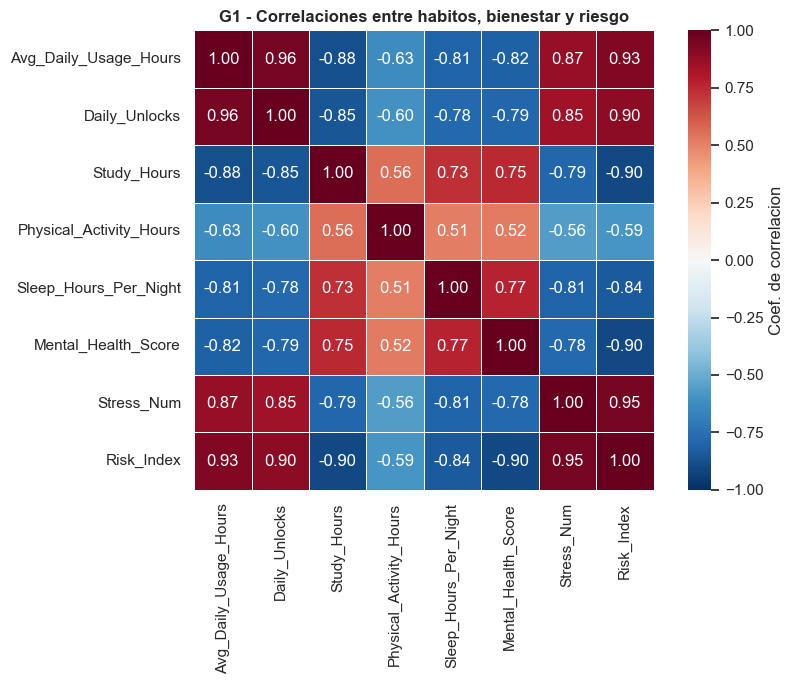

In [38]:
# G1 - Mapa de correlaciones (contexto general)
fig, ax = plt.subplots(figsize=(9, 7))
num = ["Avg_Daily_Usage_Hours", "Daily_Unlocks", "Study_Hours",
       "Physical_Activity_Hours", "Sleep_Hours_Per_Night",
       "Mental_Health_Score", "Stress_Num", "Risk_Index"]
sns.heatmap(viz[num].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, ax=ax,
            cbar_kws={"label": "Coef. de correlacion"})
ax.set_title("G1 - Correlaciones entre habitos, bienestar y riesgo", fontweight="bold")
plt.tight_layout(); plt.savefig("graficos/g1_correlaciones.png", dpi=110); plt.show()


**Analisis G1.** El `Risk_Index` se asocia **positivamente** con el uso diario de redes y los
desbloqueos, y **negativamente** con estudio, sueno y salud mental. La variable individual mas
ligada al riesgo es **`Avg_Daily_Usage_Hours`** (mayor uso -> mayor riesgo). Tambien se ve que
uso, sueno y estudio estan fuertemente correlacionados entre si: justifica analizar el **umbral**
y el **mecanismo** (Q2) y respalda haber construido el indice con estudio + estres + salud.

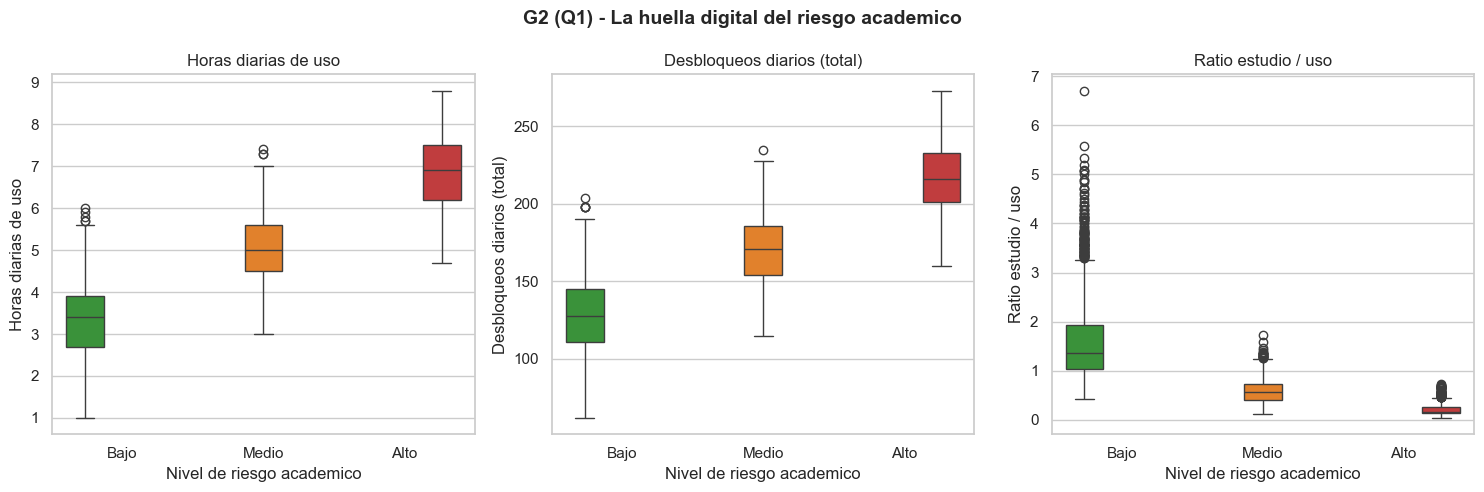

In [39]:
# G2 (Q1) - La huella digital del riesgo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metricas = [("Avg_Daily_Usage_Hours", "Horas diarias de uso"),
            ("Daily_Unlocks", "Desbloqueos diarios (total)"),
            ("Study_Usage_Ratio", "Ratio estudio / uso")]
for ax, (col, lab) in zip(axes, metricas):
    sns.boxplot(data=viz, x="Risk_Level", y=col, order=ORDEN_RISK,
                hue="Risk_Level", palette=PAL_RISK, legend=False, ax=ax)
    ax.set_xlabel("Nivel de riesgo academico"); ax.set_ylabel(lab); ax.set_title(lab)
fig.suptitle("G2 (Q1) - La huella digital del riesgo academico", fontweight="bold", fontsize=14)
plt.tight_layout(); plt.savefig("graficos/g2_q1_huella.png", dpi=110); plt.show()


**Analisis G2 (Q1).** El grupo de **riesgo Alto** dibuja una huella digital clara: usa **mas horas**
de redes (mediana ~7 h vs ~3 h del grupo Bajo), acumula **mas desbloqueos diarios** (~217 vs ~127:
revisa el celular muchas mas veces al dia) y **prioriza mucho menos el estudio** (`Study_Usage_Ratio`
~0.2 vs ~1.6). No es una sola variable: es la **combinacion** de mucho tiempo + chequeo constante +
estudio desplazado lo que caracteriza al estudiante en riesgo. Esta es la respuesta directa a la Q1.

> *Matiz:* los desbloqueos **por hora** son algo menores en el grupo de riesgo (sesiones mas largas e
> inmersivas), por eso para la huella usamos el **total diario**, que es la senal mas representativa.

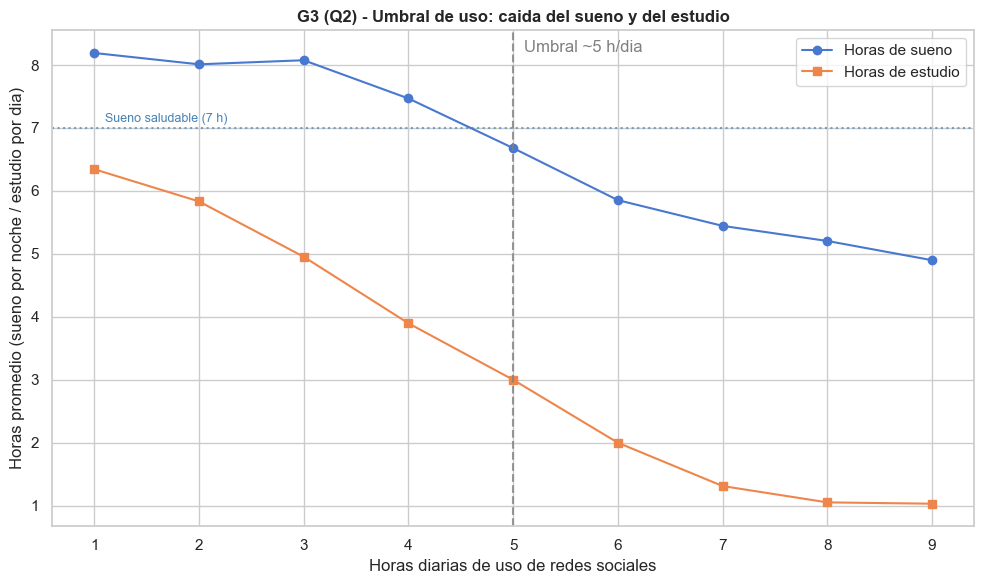

In [40]:
# G3 (Q2) - Umbral: uso vs sueno y estudio
viz["Uso_round"] = viz["Avg_Daily_Usage_Hours"].round()
agg = viz.groupby("Uso_round")[["Sleep_Hours_Per_Night", "Study_Hours"]].mean()
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(agg.index, agg["Sleep_Hours_Per_Night"], marker="o", label="Horas de sueno")
ax.plot(agg.index, agg["Study_Hours"], marker="s", label="Horas de estudio")
ax.axhline(7, ls=":", color="steelblue", alpha=.7)
ax.axvline(5, ls="--", color="grey", alpha=.8)
ax.text(5.1, 8.2, "Umbral ~5 h/dia", color="grey")
ax.text(1.1, 7.1, "Sueno saludable (7 h)", color="steelblue", fontsize=9)
ax.set_xlabel("Horas diarias de uso de redes sociales")
ax.set_ylabel("Horas promedio (sueno por noche / estudio por dia)")
ax.set_title("G3 (Q2) - Umbral de uso: caida del sueno y del estudio", fontweight="bold")
ax.legend()
plt.tight_layout(); plt.savefig("graficos/g3_q2_umbral.png", dpi=110); plt.show()


**Analisis G3 (Q2 - umbral).** Cada hora adicional de redes **erosiona** sueno y estudio, pero el
quiebre es claro: el sueno cruza por debajo de las **7 h saludables alrededor de las ~5 h/dia** de
uso, y el estudio se desploma de ~6 h (uso bajo) a ~1 h (uso alto). A partir de **~5 h diarias** el
deterioro se vuelve marcado: ese es el **umbral** que buscaba la Q2 y un corte accionable para
alertas en el dashboard.

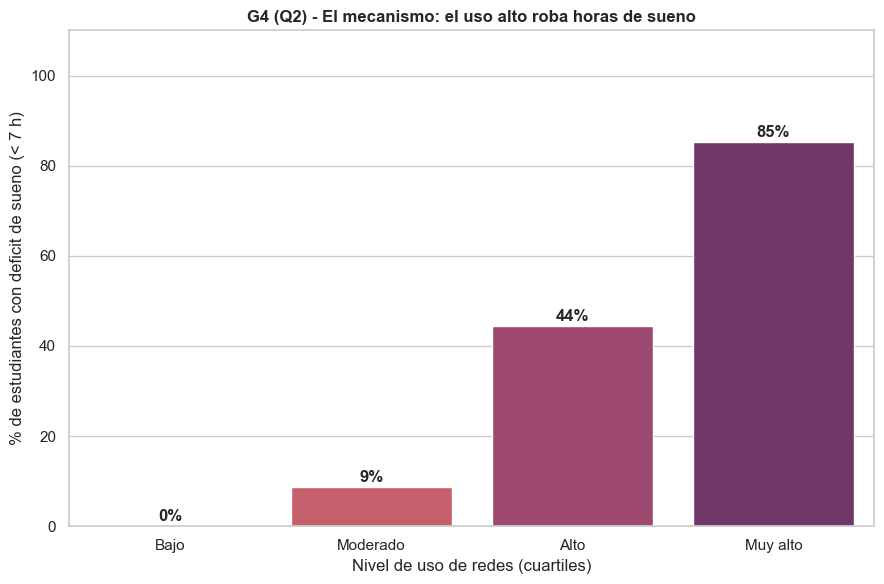

In [41]:
# G4 (Q2 - mecanismo) - % deficit de sueno por nivel de uso
defi = viz.groupby("Usage_Level", observed=True)["Sleep_Deficit"].mean().mul(100).reindex(ORDEN_USO)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=defi.index, y=defi.values, hue=defi.index, palette="flare", legend=False, ax=ax)
for i, v in enumerate(defi.values):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center", fontweight="bold")
ax.set_xlabel("Nivel de uso de redes (cuartiles)")
ax.set_ylabel("% de estudiantes con deficit de sueno (< 7 h)")
ax.set_ylim(0, 110)
ax.set_title("G4 (Q2) - El mecanismo: el uso alto roba horas de sueno", fontweight="bold")
plt.tight_layout(); plt.savefig("graficos/g4_q2_mecanismo.png", dpi=110); plt.show()


**Analisis G4 (Q2 - mecanismo).** El deficit de sueno escala de forma abrupta con el uso:
**0% -> 9% -> 44% -> 85%** del cuartil Bajo al Muy alto. Junto con G3, confirma que **la via principal
por la que el exceso de pantalla afecta el rendimiento es robando sueno**: casi todos los usuarios
intensivos duermen menos de lo recomendado. El sueno es la palanca de intervencion mas directa.

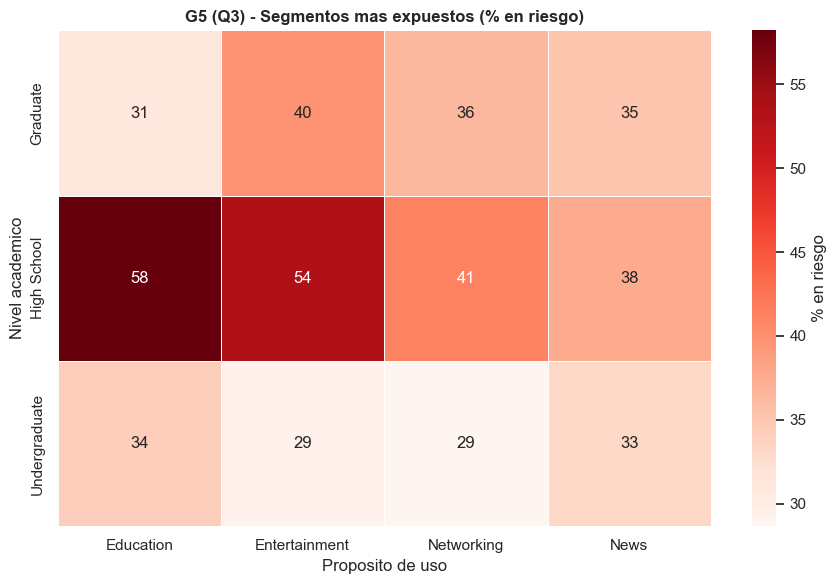

In [42]:
# G5 (Q3) - % en riesgo por nivel academico x proposito de uso
piv = viz.pivot_table(index="Academic_Level", columns="Purpose_Of_Use",
                      values="En_Riesgo", aggfunc="mean").mul(100)
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(piv, annot=True, fmt=".0f", cmap="Reds", linewidths=.5, ax=ax,
            cbar_kws={"label": "% en riesgo"})
ax.set_xlabel("Proposito de uso"); ax.set_ylabel("Nivel academico")
ax.set_title("G5 (Q3) - Segmentos mas expuestos (% en riesgo)", fontweight="bold")
plt.tight_layout(); plt.savefig("graficos/g5_q3_segmentos.png", dpi=110); plt.show()


**Analisis G5 (Q3).** El nivel **High School** es el mas expuesto (hasta **~58%** en riesgo,
sobre todo con propositos *Education* y *Entertainment*), seguido de *Graduate* con uso de
*Entertainment* (~40%); los *Undergraduate* muestran el menor riesgo (~29-34%). La prioridad de
intervencion son los **estudiantes de secundaria**. 